# Импорты и общие настройки

In [4]:
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Установка seed

In [5]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


# Генерация синтетического датасета

In [6]:
def make_synthetic_series(n_days: int = 1100, start: str = "2021-01-01") -> pd.DataFrame:
    """Генерирует реалистичный синтетический временной ряд с несколькими компонентами."""
    dates = pd.date_range(start=start, periods=n_days, freq="D")
    t = np.arange(n_days)
    trend = 60 + 0.04 * t 
    weekly = 7 * np.sin(2 * np.pi * t / 7) + 2.5 * np.cos(2 * np.pi * t / 7) 
    long_wave = 9 * np.sin(2 * np.pi * t / 365.25) 
    noise = np.random.normal(0, 2.7, size=n_days)
    dow = pd.Series(dates).dt.dayofweek.to_numpy()
    weekend_bonus = np.where(dow >= 5, 4.5, 0.0)
    promo = np.zeros(n_days)
    promo_idx = np.random.choice(np.arange(20, n_days - 20), size=18, replace=False)
    promo[promo_idx] += np.random.uniform(8, 16, size=len(promo_idx))
    regime_shift = np.where(t > int(n_days * 0.78), 6.0, 0.0)
    y = trend + weekly + long_wave + weekend_bonus + promo + regime_shift + noise
    y = np.maximum(y, 0.1) 
    return pd.DataFrame({"date": dates, "value": y})

df = make_synthetic_series()


,date,value
0,2021-01-01,63.841128
1,2021-01-02,71.353045
2,2021-01-03,72.906535
3,2021-01-04,65.481204
4,2021-01-05,54.856976


# EDA-анализ

In [ ]:
df.head()

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1100 non-null   datetime64[us]
 1   value   1100 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 17.3 KB


,count,mean,min,25%,50%,75%,max,std
date,1100,2022-07-04 12:00:00,2021-01-01 00:00:00,2021-10-02 18:00:00,2022-07-04 12:00:00,2023-04-05 06:00:00,2024-01-05 00:00:00,NaN
value,1100.0,84.860169,49.440841,72.242254,83.900193,97.536133,123.913235,16.193602


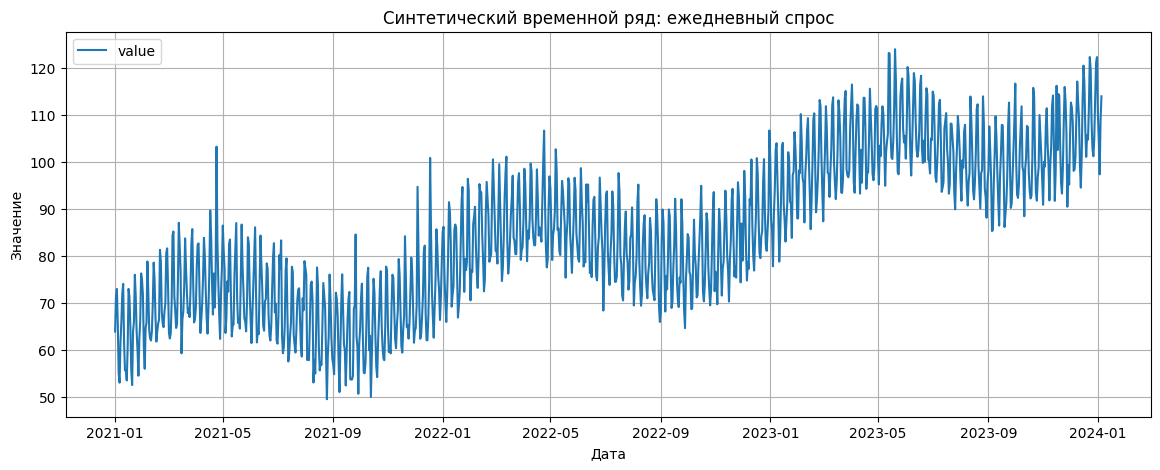

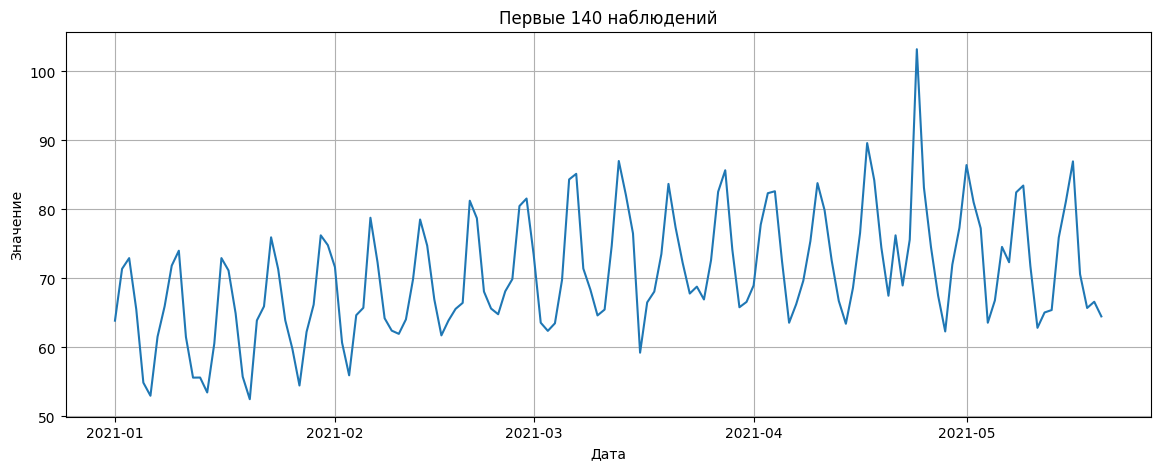

In [7]:
display(df.describe(include="all").T)

fig, ax = plt.subplots()
ax.plot(df["date"], df["value"], lw=1.5, label="value")
ax.set_title("Синтетический временной ряд: ежедневный спрос")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(df["date"].iloc[:140], df["value"].iloc[:140], lw=1.5)
ax.set_title("Первые 140 наблюдений")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
plt.show()

# Проверка пропусков в колонках

In [11]:
for column in df.columns:
    if df[column].isna().mean()*100 != 0:
        print(f"Доля пропусков в колонке {column}: {df[column].isna().mean()*100:.2f}% ")
        print(df[df[column].isna()])

# Проверка дублирующихся строк

In [12]:
print("Количество дубликатов:", df.duplicated().to_list().count(True))
print(df[df.duplicated()])

Количество дубликатов: 0
Empty DataFrame
Columns: [date, value]
Index: []
